# Laboratorio — Robot de entregas en un almacén

A partir de la **imagen**, construye el MDP y resuélvelo con **Value Iteration** y **Policy Iteration**.

![Mundo del ejercicio](https://drive.google.com/uc?export=view&id=1_sJaD57gHuiz1joEgl4B-u0aDy8jtMDo)



## Convención y notación

$$
s=(row,col)
$$

$$
T(s,a,s')=P(s'\mid s,a)
$$

$$
R(s)
$$

Para Value Iteration:

$$
V_{k+1}(s)
=
R(s)
+
\gamma
\max_a
\sum_{s'}T(s,a,s')V_k(s')
$$

Para Policy Evaluation:

$$
V_{k+1}^{\pi}(s)
=
R(s)
+
\gamma
\sum_{s'}T(s,\pi(s),s')V_k^\pi(s')
$$

### Acciones

```python
UP    = (-1, 0)
DOWN  = ( 1, 0)
LEFT  = ( 0,-1)
RIGHT = ( 0, 1)
```



## Reglas del mundo

El grid tiene **5 filas × 6 columnas**.

### Estados especiales

A partir de la imagen identifica:

- `START`
- estanterías / paredes;
- zona de entrega `+10` (**terminal**);
- estación de carga `+2` (**terminal**);
- peligro mortal `-10` (**terminal**);
- peligros `-3` (**no terminales**);
- celdas de piso resbaloso.

### Recompensa

Usamos la convención del notebook de clase, es decir, **\(R(s)\)**:

- entrega: `+10`;
- carga: `+2`;
- peligro mortal: `-10`;
- peligro: `-3`;
- cualquier otro estado transitable: `-1` (costo por paso).

### Dinámica

La transición depende del **estado actual**:

**Piso normal**

$$
P(\text{dirección elegida})=0.90
$$

$$
P(\text{desviación izquierda})=0.05
$$

$$
P(\text{desviación derecha})=0.05
$$

**Piso resbaloso**

$$
P(\text{dirección elegida})=0.60
$$

$$
P(\text{desviación izquierda})=0.20
$$

$$
P(\text{desviación derecha})=0.20
$$

Si el movimiento sale del grid o golpea una estantería, el robot **permanece en el mismo estado**.

Usa:

$$
\gamma=0.9,\qquad \theta=10^{-4}
$$



## Parte 1 — Modela el MDP

Completa la clase `WarehouseMDP`.

La parte importante no es escribir muchas líneas de código: es traducir correctamente la imagen a:

- estados;
- acciones;
- recompensas;
- terminales;
- obstáculos;
- tipos de piso;
- función de transición.


In [14]:
import numpy as np

class WarehouseMDP:
    def __init__(self):
        self.height = 5
        self.width = 6

        self.start = (0, 0)

        self.walls = {(0, 3), (1, 1), (2, 4), (4, 2)}

        self.slippery_states = {(1, 2), (2, 1), (3, 3)}

        self.terminal_states = {
            (0, 5): 10,   # entrega
            (2, 2): 2,    # carga
            (3, 5): -10,  # peligro mortal
        }

        self.danger_states = {
            (1, 4): -3,
            (4, 1): -3,
        }

        self.living_reward = -1.0
        self.gamma = 0.99

        self.actions = [
            (-1, 0),  # UP
            ( 1, 0),  # DOWN
            ( 0,-1),  # LEFT
            ( 0, 1),  # RIGHT
        ]

    def is_valid_state(self, state):
        r, c = state
        return 0 <= r < self.height and 0 <= c < self.width and state not in self.walls

    def states(self):
        return [(r, c) for r in range(self.height) for c in range(self.width)
                if (r, c) not in self.walls]

    def is_terminal(self, state):
        return state in self.terminal_states

    def get_reward(self, state):
        if state in self.terminal_states:
            return self.terminal_states[state]
        if state in self.danger_states:
            return self.danger_states[state]
        return self.living_reward

    def _rotate(self, action, direction):
        dr, dc = action
        if direction == "left":
            return (-dc, dr)
        else:
            return (dc, -dr)

    def get_transition_probs(self, state, action):
        """
        Devuelve [(next_state, probability), ...]

        - Un estado terminal no tiene transiciones reales: se queda en si mismo.
        - Las probabilidades dependen de si 'state' es resbaloso.
        - Si el movimiento sale del grid o golpea una estanteria, next_state = state.
        """
        if self.is_terminal(state):
            return [(state, 1.0)]

        if state in self.slippery_states:
            p_forward, p_side = 0.60, 0.20
        else:
            p_forward, p_side = 0.90, 0.05

        forward = action
        left = self._rotate(action, "left")
        right = self._rotate(action, "right")

        outcomes = [(forward, p_forward), (left, p_side), (right, p_side)]

        result = {}
        for a, p in outcomes:
            nr, nc = state[0] + a[0], state[1] + a[1]
            next_state = (nr, nc) if self.is_valid_state((nr, nc)) else state
            result[next_state] = result.get(next_state, 0.0) + p

        return list(result.items())



### Validación mínima del modelo

Antes de implementar Bellman, valida primero el MDP.


In [15]:
grid = WarehouseMDP()

S = grid.states()
print("Número de estados:", len(S))

for s in S:
    for a in grid.actions:
        transitions = grid.get_transition_probs(s, a)
        total = sum(p for _, p in transitions)
        assert abs(total - 1.0) < 1e-12

print("✓ Todas las distribuciones de transición suman 1.")


Número de estados: 26
✓ Todas las distribuciones de transición suman 1.



## Parte 2 — Value Iteration

Implementa:

$$
V_{k+1}(s)
=
R(s)+\gamma\max_a
\sum_{s'}T(s,a,s')V_k(s')
$$


In [16]:
def expected_next_value(grid, state, action, V):
    return sum(p * V[s2] for s2, p in grid.get_transition_probs(state, action))


def value_iteration(grid, threshold=1e-4, max_iter=10_000):
    V = {s: 0.0 for s in grid.states()}

    for i in range(max_iter):
        V_new = V.copy()
        delta = 0.0

        for s in grid.states():
            if grid.is_terminal(s):
                V_new[s] = grid.get_reward(s)
                continue

            q_values = [expected_next_value(grid, s, a, V) for a in grid.actions]
            V_new[s] = grid.get_reward(s) + grid.gamma * max(q_values)
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        if delta < threshold:
            return V, i + 1

    return V, max_iter


def extract_policy(grid, V):
    policy = {}
    for s in grid.states():
        if grid.is_terminal(s):
            continue
        policy[s] = max(grid.actions, key=lambda a: expected_next_value(grid, s, a, V))
    return policy



## Parte 3 — Policy Iteration

### Policy Evaluation

$$
V_{k+1}^{\pi}(s)
=
R(s)+\gamma
\sum_{s'}T(s,\pi(s),s')V_k^\pi(s')
$$

### Policy Improvement

$$
\pi_{\mathrm{new}}(s)
=
\arg\max_a
\sum_{s'}T(s,a,s')V^\pi(s')
$$

In [17]:
def policy_evaluation(grid, policy, threshold=1e-4, max_iter=10_000):
    V = {s: 0.0 for s in grid.states()}

    for i in range(max_iter):
        V_new = V.copy()
        delta = 0.0

        for s in grid.states():
            if grid.is_terminal(s):
                V_new[s] = grid.get_reward(s)
                continue

            a = policy[s]
            V_new[s] = grid.get_reward(s) + grid.gamma * expected_next_value(grid, s, a, V)
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        if delta < threshold:
            break

    return V


def policy_improvement(grid, V):
    return extract_policy(grid, V)


def policy_iteration(grid, threshold=1e-4, max_iter=100):
    policy = {s: grid.actions[0] for s in grid.states() if not grid.is_terminal(s)}
    history = []

    for i in range(max_iter):
        V = policy_evaluation(grid, policy, threshold)
        new_policy = policy_improvement(grid, V)

        n_changed = sum(1 for s in new_policy if new_policy[s] != policy[s])
        history.append(n_changed)

        policy = new_policy
        if n_changed == 0:
            break

    return policy, V, history



## Parte 4 — Visualización y comparación


In [18]:
ARROWS = {
    (-1, 0): "↑",
    ( 1, 0): "↓",
    ( 0,-1): "←",
    ( 0, 1): "→",
}

def print_values(grid, V):
    for r in range(grid.height):
        row = []
        for c in range(grid.width):
            s = (r, c)
            if s in grid.walls:
                row.append("  WALL  ")
            else:
                row.append(f"{V[s]:+7.3f}")
        print(" | ".join(row))


def print_policy(grid, policy):
    for r in range(grid.height):
        row = []
        for c in range(grid.width):
            s = (r, c)

            if s in grid.walls:
                row.append(" # ")
            elif grid.is_terminal(s):
                reward = grid.get_reward(s)
                row.append(f"{reward:+.0f}")
            else:
                row.append(f" {ARROWS[policy[s]]} ")

        print(" | ".join(row))


In [19]:
# VALUE ITERATION
V_vi, n_vi = value_iteration(grid)
pi_vi = extract_policy(grid, V_vi)

print("=== VALUE ITERATION ===")
print("Iteraciones:", n_vi)
print("\nValores:")
print_values(grid, V_vi)
print("\nPolítica:")
print_policy(grid, pi_vi)


# POLICY ITERATION
pi_pi, V_pi, history = policy_iteration(grid)

print("\n=== POLICY ITERATION ===")
print("Historia:", history)
print("\nValores:")
print_values(grid, V_pi)
print("\nPolítica:")
print_policy(grid, pi_pi)

assert pi_vi == pi_pi
print("\n✓ Ambos algoritmos encontraron la misma política óptima.")


=== VALUE ITERATION ===
Iteraciones: 24

Valores:
 -1.456 |  -0.310 |  +0.809 |   WALL   |  +8.601 | +10.000
 -2.179 |   WALL   |  +2.003 |  +4.118 |  +5.354 |  +8.601
 -1.081 |  +0.119 |  +2.000 |  +2.913 |   WALL   |  +7.395
 -1.606 |  -0.467 |  +0.799 |  +0.817 |  -0.359 | -10.000
 -2.752 |  -3.737 |   WALL   |  -0.359 |  -1.408 |  -2.892

Política:
 →  |  →  |  ↓  |  #  |  →  | +10
 ↓  |  #  |  →  |  →  |  →  |  ↑ 
 →  |  →  | +2 |  ↑  |  #  |  ↑ 
 →  |  →  |  ↑  |  ↑  |  ←  | -10
 ↑  |  ↑  |  #  |  ↑  |  ←  |  ← 

=== POLICY ITERATION ===
Historia: [17, 7, 2, 2, 0]

Valores:
 -1.456 |  -0.310 |  +0.809 |   WALL   |  +8.601 | +10.000
 -2.179 |   WALL   |  +2.003 |  +4.118 |  +5.354 |  +8.601
 -1.081 |  +0.119 |  +2.000 |  +2.913 |   WALL   |  +7.395
 -1.606 |  -0.467 |  +0.799 |  +0.817 |  -0.359 | -10.000
 -2.752 |  -3.737 |   WALL   |  -0.359 |  -1.408 |  -2.892

Política:
 →  |  →  |  ↓  |  #  |  →  | +10
 ↓  |  #  |  →  |  →  |  →  |  ↑ 
 →  |  →  | +2 |  ↑  |  #  |  ↑ 
 →  |  


## Parte 5 — Interpreta la política

Antes de cambiar parámetros, responde:

1. Desde `START`, ¿el robot busca la **entrega +10** o prefiere la **estación de carga +2**?
R/ Carga +2. La política en (0,0) es →, sigue → en (0,1), luego ↓ en (0,2) hacia el piso resbaloso, y termina en (2,2) = CARGA +2. Nunca sube hacia la fila 0 para llegar a (0,5).
2. ¿Por qué una recompensa menor podría ser óptima?
R/ Porque que no se maximiza la recompensa terminal sola, sino el retorno descontado total. Llegar a +10 necesita más pasos (cada uno cuesta -1) y involucra mas riesgos. Con γ=0.9, esos pasos extra y el riesgo devalúan tanto el +10 que terminar antes en +2 rinde más.
3. ¿En qué estados el piso resbaloso cambia la decisión?
R/ En (2,1): ahí no importa tanto porque las celdas vecinas no son peligrosas, entonces conviene arriesgarse e ir directo a la carga.
4. ¿Qué papel cumple el costo por paso `-1`?
R/ Sin él, no habría diferencia entre tardar 3 o 15 pasos en llegar a un terminal, y siempre convendría ir por el +10.
5. ¿Por qué \(T(s,a,s')\) ya no puede implementarse con las mismas probabilidades para todos los estados?
R/ Porque la dinámica depende del tipo de piso del estado actual. Como slippery_states es un subconjunto de las celdas, la distribución de transición cambia según en qué estado estés parado.


### Experimento A — Menos costo por paso

Cambia:

```python
living_reward = -0.1
```

Predice la política **antes de ejecutar**.

R/
- Predicción: Predecimos que con living_reward=-0.1 la política cambiará hacia +10, porque el costo por paso deja de penalizar tanto los caminos largos.
- Resultados: La política cambió, antes iba a +2, ahora va a +10. Con -0.1 el costo de caminar es tan bajo que ya no compensa conformarse con la recompensa menor. <br>
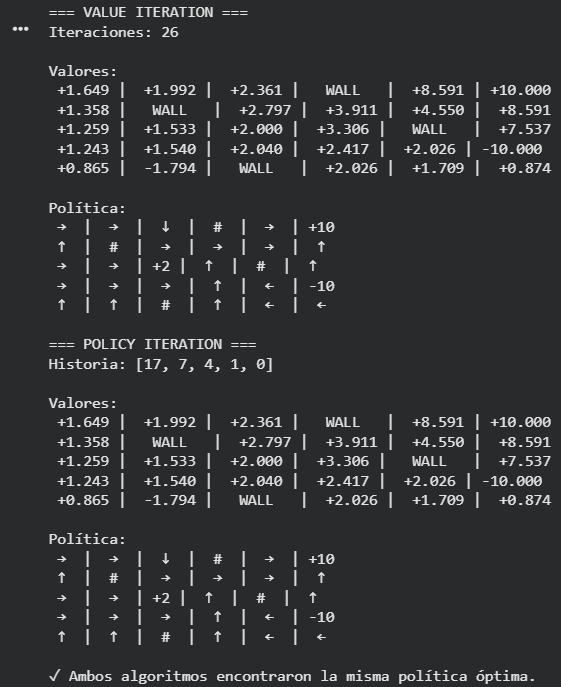

### Experimento B — Piso muy resbaloso

Cambia la probabilidad de movimiento deseado del piso resbaloso:

```python
0.60 → 0.40
```

y reparte el restante entre las dos desviaciones.

/R
- Predicción: Pensamos que la política debería evitar más las celdas resbalosas, porque ahora es más probable "resbalar" hacia un lado no deseado.

- Resultados: la política se mantuvo igual; solo los valores bajaron (más riesgo = menos valor esperado, pero la ruta óptima no cambia porque las desviaciones no llevan a estados mucho peores). <br>
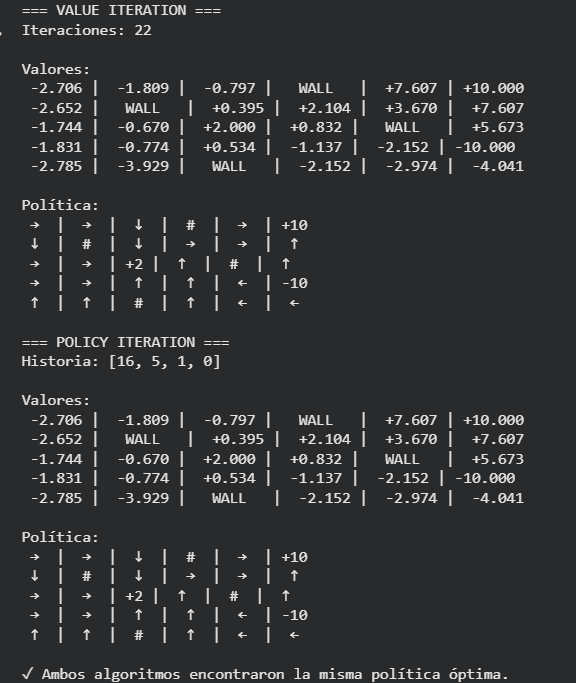

### Experimento C — Más paciencia

Cambia:

```python
gamma = 0.99
```

¿La política valora más la recompensa `+10` distante?

R/

Predicción: +10 debería pesar casi tanto como si estuviera cerca. pensamps que ahora sí vale la pena ir por la entrega +10 en vez de conformarse con +2.

Resultados: La política cambió en (1,2), y eso redirige todo el camino desde START hacia la entrega +10 en vez de la carga +2. <br>
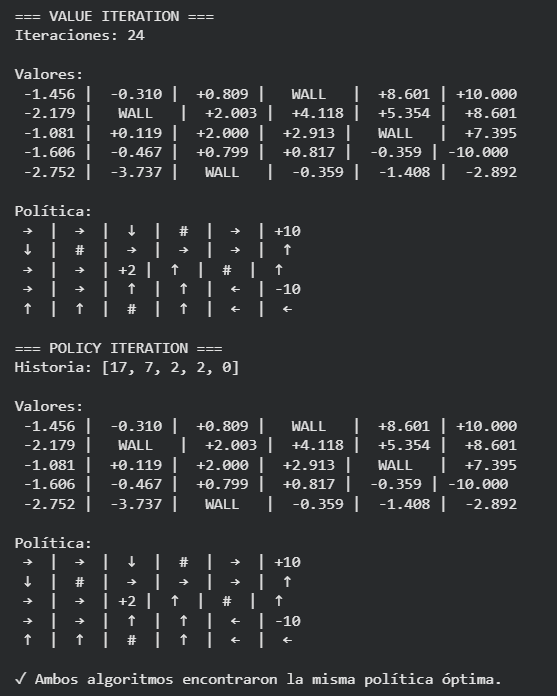


### Bonus

Encuentra aproximadamente el valor de `living_reward` a partir del cual la política desde `START` cambia entre:

- ir a carga `+2`;
- intentar llegar a entrega `+10`.
